In [1]:
#Question 1 
import numpy as np
import matplotlib.pyplot as plt
from assignment3py import complex_z

C, iter_counts = complex_z(max_iter = 100)

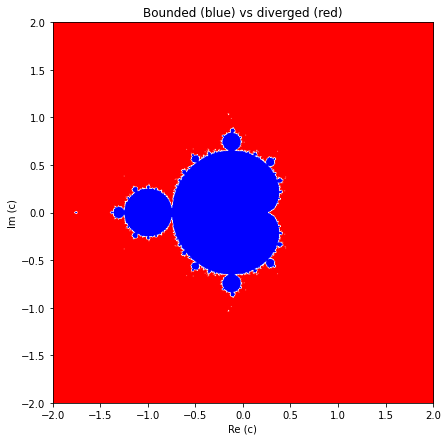

In [2]:
# Image 1: bounded vs diverged
two_colour = np.where(iter_counts == 100, 0, 1)
plt.figure(figsize=(7, 7))
plt.imshow(two_colour, extent=[-2, 2, -2, 2], origin='lower', cmap='bwr', interpolation='bilinear') #bilinear interpolation is giving more sharper boundaries between red and blue
plt.title("Bounded (blue) vs diverged (red)")
plt.xlabel("Re (c)")
plt.ylabel("Im (c)")
plt.show()

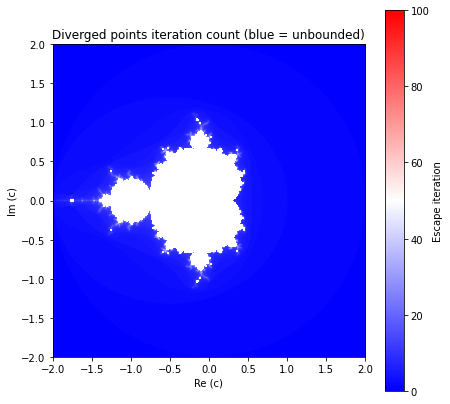

In [34]:
# Image 2: coloured by escape iteration
display = iter_counts.astype(float)
display[iter_counts == 100] = np.nan

#Figure 
plt.figure(figsize=(7, 7))
plt.imshow(display, extent=[-2, 2, -2, 2], origin='lower', cmap='bwr', interpolation='bilinear', vmin=0, vmax=100)
plt.colorbar(label="Escape iteration")
plt.title("Diverged points iteration count (blue = unbounded)")
plt.xlabel("Re (c)")
plt.ylabel("Im (c)")
plt.show()

In [4]:
#Question 2 
from scipy.integrate import solve_ivp

def lorenz(t, W, sigma, r, b):
    """
    This function returns Lorenz equations with X_dot, Y_dot, and Z_dot in a list
    
    Parameters:
    ______________
    t : float (time)
    W : array [X,Y,Z]
    sigma: float (Prandtl number, the ratio of the kinematic viscocity to the thermal diffusivity)
    r : float (Rayleigh Number)
    b : float (dimensionless length scale)
    
    
    Returns:
    _______________
    List of [X_dot, Y_dot, Z_dot]
    """
    X, Y, Z = W
    X_dot = -sigma * (X - Y)
    Y_dot = r * X - Y - X * Z
    Z_dot = - b * Z + X * Y
    return [X_dot, Y_dot, Z_dot]

#Using an ODE Solver 
#initial conditions 
sigma, r, b = 10, 28, 8/3
W0 = [0, 1, 0]
dt = 0.01

t_span = (0, 60)
t_eval = np.arange(0, 60, dt)

sol = solve_ivp(lorenz, t_span, W0, args = (sigma, r, b), t_eval = t_eval)
X, Y, Z = sol.y
N = sol.t / dt

print(sol.t)

[0.000e+00 1.000e-02 2.000e-02 ... 5.997e+01 5.998e+01 5.999e+01]


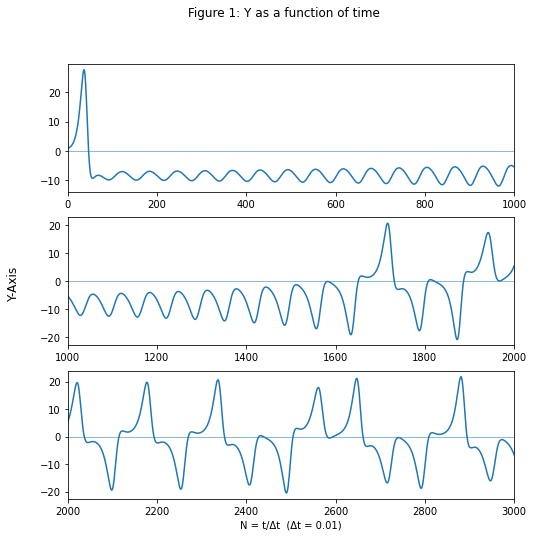

In [5]:
#Figure 1 
fig, axes = plt.subplots(3, 1, figsize=(8, 8))
ranges = [(0, 1000), (1000, 2000), (2000, 3000)]

for ax, (n_start, n_end) in zip(axes, ranges):
    mask = (N >= n_start) & (N <= n_end)
    ax.plot(N[mask], Y[mask])  # keep actual N values, no subtraction
    ax.set_xlim(n_start, n_end)
    ax.axhline(0, linewidth=0.5)

axes[2].set_xlabel("N = t/Δt  (Δt = 0.01)")
fig.suptitle("Figure 1: Y as a function of time")
fig.supylabel('Y-Axis')
plt.show()

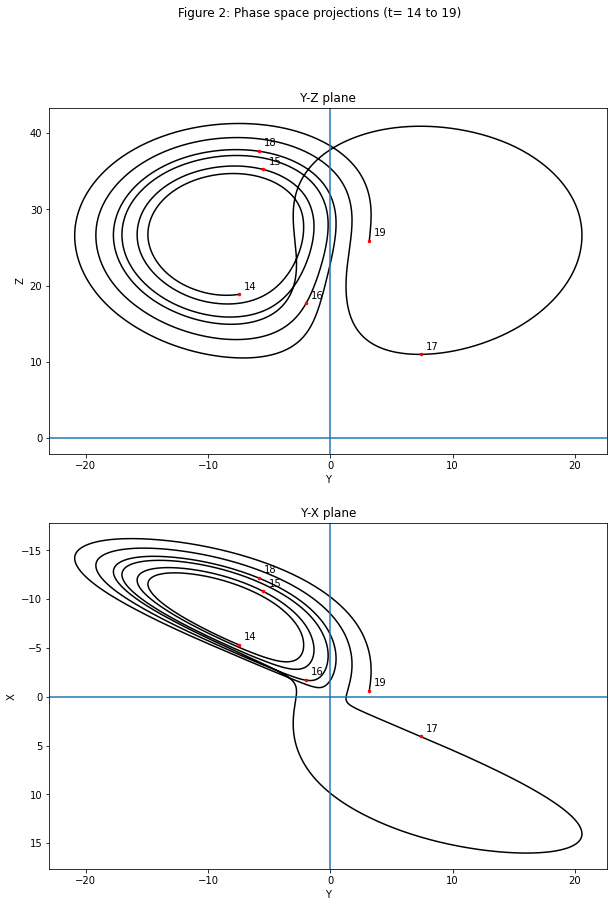

In [7]:
# Figure 2
t_fine = np.linspace(14, 19, 5000) 
sol2 = solve_ivp(lorenz, (0, 19), W0, args = (sigma, r, b), t_eval = t_fine)
X2, Y2, Z2 = sol2.y

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 14))

# Top: Y-Z plane
ax_top.plot(Y2, Z2, 'black')
ax_top.set_xlabel("Y")
ax_top.set_ylabel("Z")
ax_top.set_title("Y-Z plane")
ax_top.axhline(0)
ax_top.axvline(0)

# Bottom: Y-X plane (Y on x-axis, X on y-axis — matching Lorenz Fig 2)
ax_bot.plot(Y2, X2, 'black')
ax_bot.invert_yaxis()
ax_bot.set_xlabel("Y")
ax_bot.set_ylabel("X")
ax_bot.set_title("Y-X plane")
ax_bot.axhline(0)
ax_bot.axvline(0)

times = [14, 15, 16, 17, 18, 19]
for t in times:
    value = np.argmin(np.abs(t_fine - t))
    ax_top.plot(Y2[value], Z2[value], '.' , markersize = 5, color = 'red')
    ax_top.annotate(str(t), (Y2[value], Z2[value]), textcoords="offset points",
                    xytext=(5, 5), fontsize=10)
    ax_bot.plot(Y2[value], X2[value], '.' , markersize = 5, color = 'red')
    ax_bot.annotate(str(t), (Y2[value], X2[value]), textcoords="offset points",
                    xytext=(5, 5), fontsize=10)

fig.suptitle("Figure 2: Phase space projections (t= 14 to 19)")
plt.show()

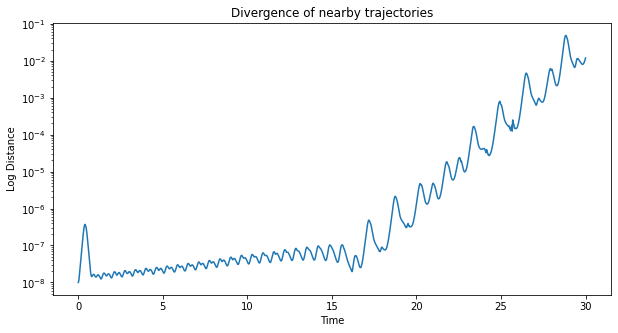

In [33]:
W0_prime = [W0[i] + p for i, p in enumerate([0., 1e-8, 0.])]
t_span = (0, 30)
t_eval = np.linspace(0, 30, 3000)

sol = solve_ivp(lorenz, t_span, W0, args=(sigma, r, b), t_eval = t_eval)
sol_prime = solve_ivp(lorenz, t_span, W0_prime, args=(sigma, r, b), t_eval = t_eval)

X, Y, Z  = sol.y
Xp, Yp, Zp = sol_prime.y
distance = np.sqrt((X - Xp)**2 + (Y - Yp)**2 + (Z - Zp)**2)

plt.figure(figsize=(10, 5))
plt.semilogy(sol.t, distance)
plt.xlabel('Time')
plt.ylabel('Log Distance')
plt.title('Divergence of nearby trajectories')
plt.show()